## How has country dominance evolved in the Winter Olympics?

Every year, with the Winter Olympics dominating the cultural conversation, it is always intersting to see which of the top countries dominate in what sports. I am particularly interested in figure skaing. Thus, I associate Japan, Russia (competing under a neutral entity), and the US dominate the figure skating conversaion. In this data story, I am looking to see which countries dominate, and which countries have led to upsets–such as this year 2026 with Kazakhstan's Mikhail Shaidorov winning the men's singles. Have these associations between country and sports evolved over time? If so, how so?

### For each sport, which country dominates overall?

In [35]:
import pandas as pd

# Load datasets with the 'data/' path
df_medals = pd.read_csv('data/winter_olympics_medals.csv')

# Identify "Major Sports" by athlete count.participation
top_sports = df_medals.groupby('discipline')['athlete_id'].nunique().sort_values(ascending=False).head(5).index.tolist()

# Identify the all-time dominant country for these sports
golds = df_medals[df_medals['medal'] == 'Gold']
dominance = golds[golds['discipline'].isin(top_sports)].groupby(['discipline', 'noc']).size().reset_index(name='Gold Count')
top_powers = dominance.sort_values(['discipline', 'Gold Count'], ascending=[True, False]).groupby('discipline').head(1)

top_powers

,discipline,noc,Gold Count
0,Alpine Skiing (Skiing),AUT,50
23,Bobsleigh (Bobsleigh),GER,46
41,Cross Country Skiing (Skiing),NOR,90
49,Ice Hockey (Ice Hockey),CAN,235
73,Speed Skating (Skating),NED,55


From this table, we can see for every single sport, what is the country that dominates the winnings, alongside how many gold medals the country has won for the sport. This table is sorted by alphabetical of what the sport is. 

### Is there power in numbers? How does population affect talent pool?

Overall, we can observe that countries with very small populations rarely make the podium, and very frequently in the news, we hear of atheletes moving to the United States and other world powers to train and get the opportunity to compete. I would like to explore the ways that population size affects Olympic dominance.  For countries with smaller populations, how do they overcome these barriers with infrastructure to spot and develop talent?

We define efficiency as the total number of medals for all sports per capita. We also define sport specific efficiency as the total number of medals for a specific sport per capita.

/tmp/ipykernel_2121364/635621983.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_efficient, x='medals_per_million', y='noc', palette='magma')


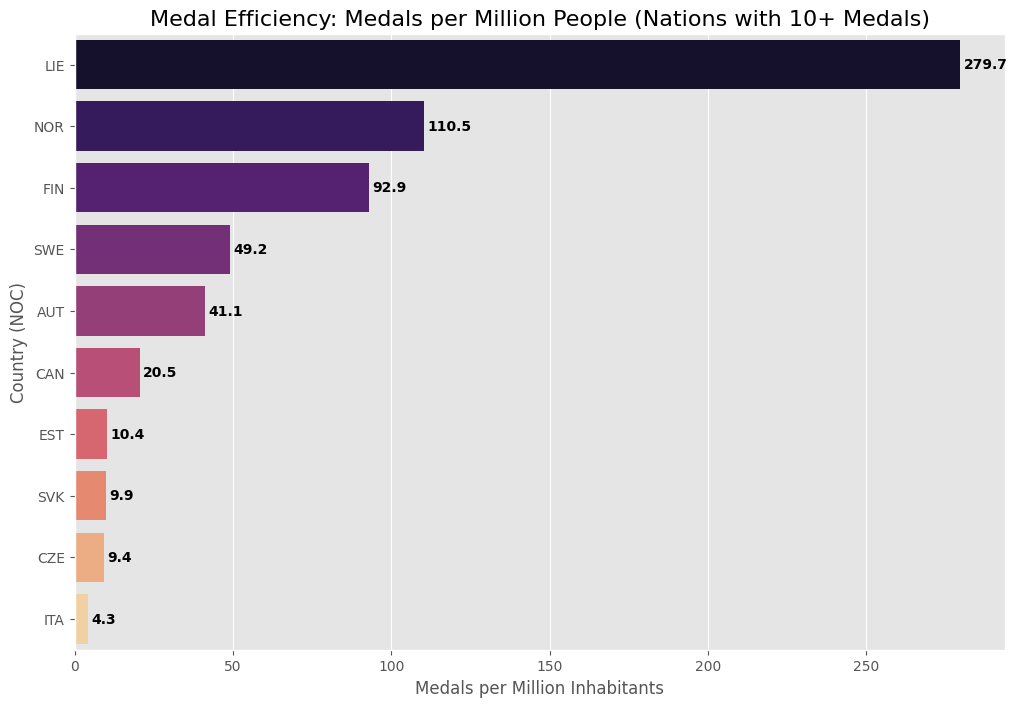

In [36]:
import seaborn as sns
df_pop = pd.read_csv('data/populations.csv')

# Aggregate total medals (all-time) by NOC
medal_counts = df_medals[df_medals['medal'].notna()].groupby('noc').size().reset_index(name='total_medals')

# Extract 2022 Population figures
pop_2022 = df_pop[['Country Code', '2022']].rename(columns={'Country Code': 'noc', '2022': 'population'})

# Merge medal data with population data
efficiency_df = medal_counts.merge(pop_2022, on='noc', how='inner')

# Calculate Medals per Million People
efficiency_df['medals_per_million'] = (efficiency_df['total_medals'] / efficiency_df['population']) * 1_000_000

# Filter for nations with at least 10 medals to ensure statistical significance
top_efficient = efficiency_df[efficiency_df['total_medals'] >= 10].sort_values('medals_per_million', ascending=False).head(10)

# Visualization
plt.style.use('ggplot')
plt.figure(figsize=(12, 8))
sns.barplot(data=top_efficient, x='medals_per_million', y='noc', palette='magma')

plt.title('Medal Efficiency: Medals per Million People (Nations with 10+ Medals)', fontsize=16)
plt.xlabel('Medals per Million Inhabitants', fontsize=12)
plt.ylabel('Country (NOC)', fontsize=12)

# Annotate bars with the exact efficiency score
for i, v in enumerate(top_efficient['medals_per_million']):
    plt.text(v + 1, i, f"{v:.1f}", color='black', va='center', fontweight='bold')

From this graph, we can observe the most "efficent" countries. This graph displays the relationship between a country's population and how many medals they win. Lichenstein dominates as they have the most medals per millions of inhabitants. Although the population of countries like Liechtenstein and Norway have a fraction of the population of the United States, they produce over 40 times as many medals per capita. 

It is important to note thought that structurally, they have an advantage due to climate. The winter olympics are largely sports that take place in the snow and ice. Thus, since these countries are largely covered by snow and ice during a larger portion of the year (compared to the countries of larger populations such as the USA), more people proportionally have the opportunity to develop their skills from a young age such that they can be competitors in the Olympics. 

### Does dominance in a major sport require high population to medal ratio?

For the sports with the greatest number of participants, we will compare what countries have the most medals in each of these sports. Within this result, we will compare for countries with high efficinecy as defined above, how much of that efficiency is dedicated to this specific sport in which they dominate. Thus, we will be able to udnerstand whether their dominance is spread across multiple sports or through just one particular sport. 

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
df_medals = pd.read_csv('data/winter_olympics_medals.csv')
df_pop = pd.read_csv('data/populations.csv')

# Re-identify the Top 5 Major Sports and their Dominant Nations
# Top 5 Major Sports are defined by the number of participants.
top_sports = df_medals.groupby('discipline')['athlete_id'].nunique().sort_values(ascending=False).head(5).index.tolist()
golds = df_medals[df_medals['medal'] == 'Gold']
dominance = golds[golds['discipline'].isin(top_sports)].groupby(['discipline', 'noc']).size().reset_index(name='Gold_Count')
top_powers = dominance.sort_values(['discipline', 'Gold_Count'], ascending=[True, False]).groupby('discipline').head(1)

# Map NOC codes to World Bank population codes (handling specific differences)
noc_to_iso = {'GER': 'DEU', 'NED': 'NLD', 'SUI': 'CHE', 'LAT': 'LVA', 'ROC': 'RUS', 'URS': 'RUS'}
top_powers['pop_code'] = top_powers['noc'].apply(lambda x: noc_to_iso.get(x, x))

# Calculate Efficiency (Medals per Million) for 2022
medal_counts = df_medals[df_medals['medal'].notna()].groupby('noc').size().reset_index(name='total_medals')
medal_counts['pop_code'] = medal_counts['noc'].apply(lambda x: noc_to_iso.get(x, x))

pop_2022 = df_pop[['Country Code', '2022']].rename(columns={'Country Code': 'pop_code', '2022': 'population'})
efficiency_df = medal_counts.merge(pop_2022, on='pop_code', how='inner')
efficiency_df['efficiency'] = (efficiency_df['total_medals'] / efficiency_df['population']) * 1_000_000

# Merge results to compare Dominance with Efficiency
comparison = top_powers.merge(efficiency_df[['pop_code', 'efficiency', 'population']], on='pop_code', how='left')
comparison['sport_specific_efficiency'] = (comparison['Gold_Count'] / comparison['population']) * 1_000_000

# Print the comparison
print(comparison[['discipline', 'noc', 'Gold_Count', 'efficiency', 'sport_specific_efficiency']])

                      discipline  noc  Gold_Count  efficiency  \
0         Alpine Skiing (Skiing)  AUT          50   41.142018   
1          Bobsleigh (Bobsleigh)  GER          46    6.706605   
2  Cross Country Skiing (Skiing)  NOR          90  110.497703   
3        Ice Hockey (Ice Hockey)  CAN         235   20.544925   
4        Speed Skating (Skating)  NED          55   10.394904   

   sport_specific_efficiency  
0                   5.529841  
1                   0.548939  
2                  16.492195  
3                   6.035072  
4                   3.107172  


 Since the top five sports are defined by the number of participants, this data is slightly skewed to reflect sports that are able to have larger amounts of competitors, as the number of competitors isn't standard across events and sports. Keeping this in mind, my observations are as follows: 

In speed skating, Norway is the outlier, as they dominate in both the number of golds and in having the largest number of medals per capita. The ratio of 16.49 golds per million people is higher than often the toal medal efficiency of many major nations like the United States (2.3).  One reason for this might be because there are many sports that are valued in the United States. Within the US alone, a lot of press and money is generated for American football. Furthermore, due to the diverse population and climate, a lot of different sports such as soccer, beach volleyball, tennis, etc. are supported in the US. 

Nations like Germany and the Netherlands dominate their respective sports (Bobsleigh and Speed Skating) in absolute numbers, yet they rank lower in overall population efficiency.

Countries like Canada and Austria  are significantly more efficient than global giants like the USA or Russia, but their dominance in Ice Hockey and Alpine Skiing is also supported by a larger population than Norway's, allowing them to sustain high participation volumes across decades.



### How has dominance evolved in figure skating?

In my circles, figure skating has dominated the conversation both on my social media feed, and in in-person conversations. Thus, I wanted to explore the ways that a country's dominance has shifted this cultural conversation. One way to observe this is by investigating how countries have dominated the podium throughout the years. 


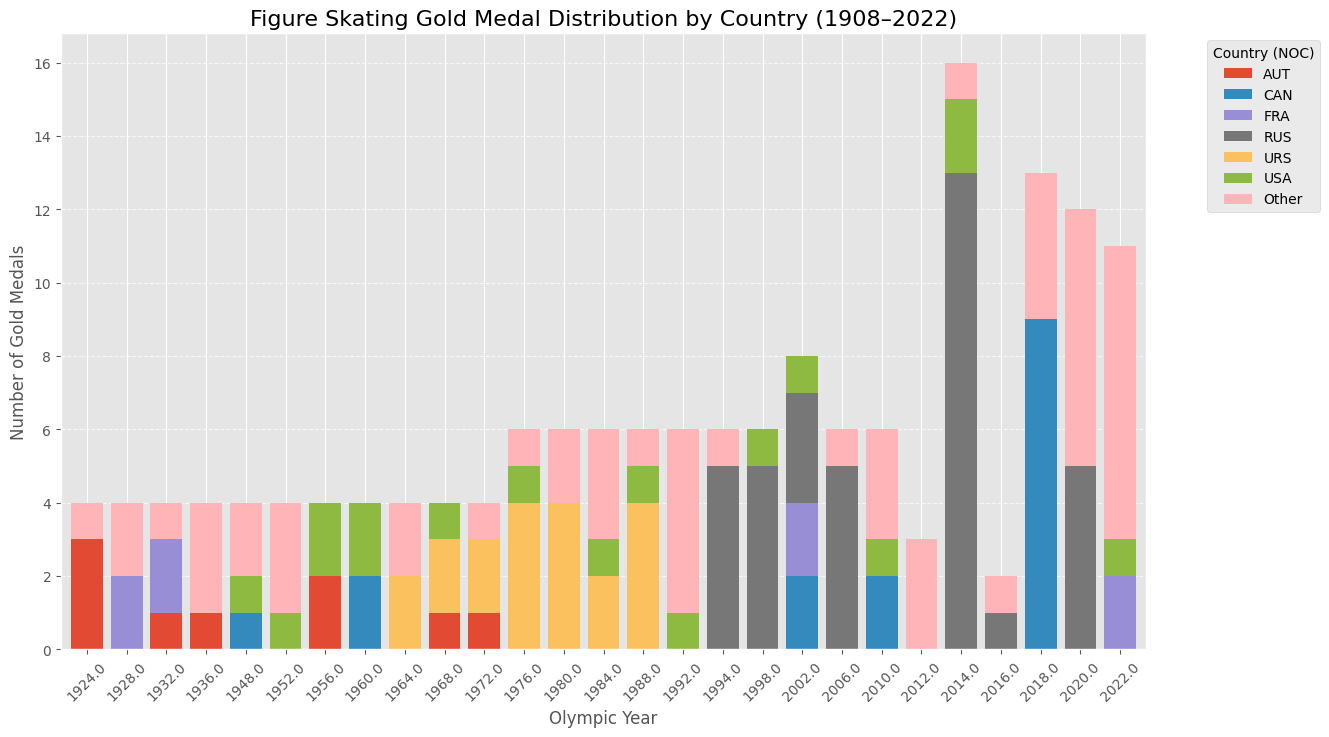

In [34]:
import matplotlib.pyplot as plt

# Filter for Figure Skating Gold Medals
skating_golds = df_medals[(df_medals['discipline'].str.contains('Figure Skating', na=False)) & 
                           (df_medals['medal'] == 'Gold')].copy()

# Identify the top 6 all-time winning nations
top_nocs = skating_golds['noc'].value_counts().head(6).index.tolist()

# Group NOCs into top performers or "Other"
skating_golds['noc_group'] = skating_golds['noc'].apply(lambda x: x if x in top_nocs else 'Other')

# Pivot the data to get gold counts per year per nation group
plot_data = skating_golds.groupby(['year', 'noc_group']).size().unstack(fill_value=0)

# Reorder columns to place 'Other' at the end for visual clarity
cols = [c for c in plot_data.columns if c != 'Other'] + ['Other']
plot_data = plot_data[cols]

# Create a stacked bar chart
plt.style.use('ggplot')
ax = plot_data.plot(kind='bar', stacked=True, figsize=(14, 8), width=0.8)

plt.title('Figure Skating Gold Medal Distribution by Country (1908–2022)', fontsize=16)
plt.xlabel('Olympic Year', fontsize=12)
plt.ylabel('Number of Gold Medals', fontsize=12)
plt.legend(title='Country (NOC)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

The resulting data reveals a clear narrative of how dominance has evolved in figure skating:

To start, we identify the top countries in the visualization by identifying the top 6 all-time winning nations to keep their names distinct. All other countries are in the "Other" category.

Early Era (1908–1950s): The sport's early history was characterized by a tug-of-war between Austria (AUT), the United States (USA), and France (FRA). The podiums were relatively small, with fewer events than today. 

The Soviet/Russian Rise (1960s–2000s): Starting in the 1960s, the Soviet Union (URS) became a powerhouse, particularly in Pairs and Ice Dance. Following the dissolution of the USSR, Russia (RUS) maintained this strength throughout the 1990s and 2000s. Furthermore, in the 1970s, we see the introduction of more events, and thus more opportunities for a country to earn medals. 

The Modern Expansion (2010s–Present): The most significant trend in recent years is the growth of the "Other" category and the rise of Canada (CAN) and China (CHN). The "Other" bar now includes high-performing nations like Japan and South Korea, signaling that the technical knowledge and training infrastructure required for gold are no longer concentrated in just two or three countries. However, it is important to note the significant spike in 2014 where RUS dominated the podium. This has since been diminished significantly in later years, suggesting that Russia has been unable to maintain this momentum, and that this year and dominance is an outlier. 

### Should we change how we predict wins in figure skating?

From what we can see above, if more "Other" countries are winning medals over time, this means that it will be harder to predict wins just based on country, making Mikhail Shaidorov’s 2026 win not that suprising in retrospect. 

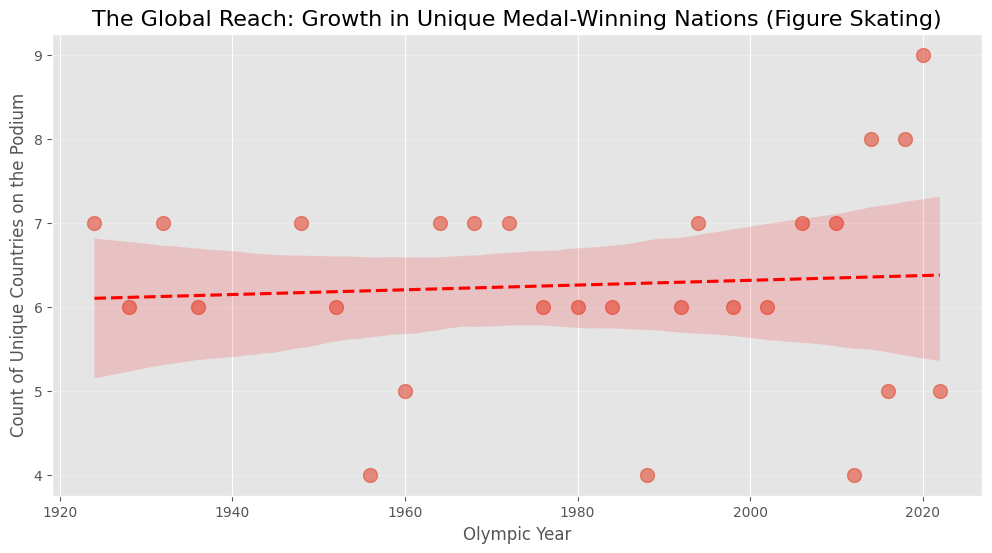

In [39]:


# Filter for all Figure Skating medals
fs_medals = df_medals[df_medals['discipline'].str.contains('Figure Skating', na=False, case=False)].dropna(subset=['medal'])

# 2. Count unique countries (NOCs) that won at least one medal in each Olympic year
diversity = fs_medals.groupby('year')['noc'].nunique().reset_index()

# 3. Visualization: The "Expansion of the Podium"
plt.figure(figsize=(12, 6))
sns.regplot(data=diversity, x='year', y='noc', scatter_kws={'s':100, 'alpha':0.6}, line_kws={'color':'red', 'ls':'--'})

plt.title('The Global Reach: Growth in Unique Medal-Winning Nations (Figure Skating)', fontsize=16)
plt.ylabel('Count of Unique Countries on the Podium', fontsize=12)
plt.xlabel('Olympic Year', fontsize=12)
plt.grid(axis='y', alpha=0.3)

Each of the red dots present specific Olympic year. For instance, a dot at the year 1924 with a height of 7 means that in those first games, 7 different countries shared the medals. The red dahsed line is the overall trend line, as it is a linear regression line. From what we can observe here, the number of unique countries on the podium in figure skating has increased over time as the red line has sloped upwards. The average number of unique countries winning medals has steadily increased from about 5 or 6 medals in the early 1900s to nearly 9 or 10 now. 

## Conclusion

In conclusion, country dominance in the winter olympics is due to a myriad of reasons. It can be due to geographical and cultural reasons, where in the case of Norway, access to ski facilities and a culture of skiing gives rise to lots of top talent. It can also be due to building up an infrastructure of identifying and training top talent as a country's economy expands in the modern age, leading to the influx of winners coming from countries that have historically not dominated. These changes, combined with the sheer athleticism on display make the olympics a thrilling watch, and I am eager to perform more analysis in the future!